In [ ]:
%load_ext autoreload
%autoreload 2

#### 1. 测试FIOS的误差预算曲线

In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os
import re
import sys
import math
import time
import tempfile
import traceback
from typing import List, Dict, Tuple
import pandas as pd
import numpy as np
import json
project_root = "/home/wangshuo/projects/Neo4j_Exp"
if project_root not in sys.path:
    sys.path.append(project_root)
from pythonProject.src.Structure_first.proxy_sample import run_fois_budget_curve_multi_predicate

budget_fracs = [0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5]

df_curve = run_fois_budget_curve_multi_predicate(
    dataset_name="dataset_three",
    budget_fracs=budget_fracs,
    run_times=5,
    post_proxy_col="ML1_proxy4b_probability",
    comment_proxy_col="ML2_proxy1_probability",
    post_oracle_col="ML1_oracle2_probability",
    comment_oracle_col="ML2_oracle2_probability"
)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 平均误差 vs 预算比例
df_plot = df_curve.groupby("budget_frac")["Qerror"].mean().reset_index()

plt.figure(figsize=(7,5))
sns.lineplot(data=df_plot, x="budget_frac", y="Qerror", marker="o")
plt.xlabel("Oracle Budget Fraction")
plt.ylabel("Mean Absolute Relative Error")
plt.title("FOIS_nrs Error vs Oracle Budget (Multi-Predicate)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# 平均误差 vs 实际 oracle_cost
df_plot2 = df_curve.groupby("oracle_cost")["Qerror"].mean().reset_index()

plt.figure(figsize=(7,5))
sns.lineplot(data=df_plot2, x="oracle_cost", y="Qerror", marker="o")
plt.xlabel("Oracle Cost (Unique Post+Comment)")
plt.ylabel("Mean Absolute Relative Error")
plt.title("FOIS_nrs Error vs Oracle Cost")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

#### 2. FOIS_nrs \ FOIS_rs \ 三种方法的曲线

##### 2.1   FOIS_nrs \ FOIS_rs曲线

In [ ]:
import os
import re
import sys
import math
import time
import tempfile
import traceback
from typing import List, Dict, Tuple
import pandas as pd
import numpy as np
import json
project_root = "/home/wangshuo/projects/Neo4j_Exp"
if project_root not in sys.path:
    sys.path.append(project_root)

budget_fracs = [0.01,0.05, 0.1, 0.15, 0.2,0.25,0.3, 0.4, 0.5,0.6,0.7,0.8,0.9]
from pythonProject.src.Structure_first.proxy_sample import run_budget_curve_multi_predicate
df_curve = run_budget_curve_multi_predicate(
    dataset_name="dataset_test3",
    budget_fracs=budget_fracs,
    run_times=5,
    post_proxy_col="ML1_proxy4b_probability",
    comment_proxy_col="ML2_proxy1_probability",
    post_oracle_col="ML1_oracle2_probability",
    comment_oracle_col="ML2_oracle2_probability"
)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ==========================================
# 1. 配置文件路径
# ==========================================
# 请根据你的实际情况修改 dataset_name
dataset_name = 'dataset_one' 
file_path = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results/budget_curve/FOIS_rs_POSS_budget_curve.csv"

# ==========================================
# 2. 读取数据
# ==========================================
if not os.path.exists(file_path):
    print(f"[Error] 文件不存在: {file_path}")
else:
    print(f"正在读取文件: {file_path}")
    df_curve = pd.read_csv(file_path)

    # 打印前几行检查数据是否正确
    print(df_curve.head())

    # ==========================================
    # 3. 数据聚合 (计算平均误差)
    # ==========================================
    # 按照 方法 和 预算比例 分组，计算 Qerror 的平均值
    df_plot = df_curve.groupby(["method", "budget_frac"])["Qerror"].mean().reset_index()

    # ==========================================
    # 4. 绘图
    # ==========================================
    # 设置学术风格
    sns.set_style("whitegrid")
    plt.figure(figsize=(8, 6))

    # 绘制折线图
    # style="method" 会自动给不同方法分配不同的线型/标记，适合黑白打印
    sns.lineplot(
        data=df_plot, 
        x="budget_frac", 
        y="Qerror", 
        hue="method", 
        style="method", 
        markers=True, 
        dashes=False, # 如果不喜欢虚线，设为 False
        markersize=8,
        linewidth=2
    )

    # 设置标签和标题
    plt.xlabel("Oracle Budget Fraction (Sampling Ratio)", fontsize=12, fontweight='bold')
    plt.ylabel("Mean Absolute Relative Error", fontsize=12, fontweight='bold')
    plt.title(f"Error Convergence: {dataset_name}", fontsize=14)

    # 可选：如果误差下降很快，建议使用对数坐标
    # plt.yscale('log') 
    # plt.xscale('log') # 预算跨度大时也建议开启

    plt.grid(True, which="both", linestyle="--", alpha=0.5)
    plt.legend(title="Method", fontsize=10, title_fontsize=11)
    
    plt.tight_layout()
    plt.show()

##### 2.2 POSS 曲线

In [ ]:
import os
import re
import sys
import math
import time
import tempfile
import traceback
from typing import List, Dict, Tuple
import pandas as pd
import numpy as np
import json
project_root = "/home/wangshuo/projects/Neo4j_Exp"
if project_root not in sys.path:
    sys.path.append(project_root)
from pythonProject.src.Structure_first.proxy_sample import run_adaptive_sampling_experiment


run_adaptive_sampling_experiment(dataset_name="dataset_test", run_times=5)

#### 3.基线方法 FastestO

In [ ]:
import os
import re
import sys
from typing import List, Dict, Tuple
import pandas as pd
import numpy as np
import json
project_root = "/home/wangshuo/projects/Neo4j_Exp"
if project_root not in sys.path:
    sys.path.append(project_root)
from pythonProject.src.Structure_first.fastest_pipeline import FastestGraphConverter, FastestEstimateMerger
from pythonProject.src.Structure_first.graph_sample import FastestRunner
from pythonProject.src.Structure_first.precision_submatching import ExactSubgraphMatcher
from pythonProject.src.Structure_first.proxy_sample import ProxyStratifiedSampler, compute_T_true

# 一级测试数据集
datasets_name = "parler_data"
# 一级数据集下根据查询和图结构的差异划分的子测试数据集
dataset_name = "dataset_three"
current_budget = 20000

# 初始化 Runner

infer_label = 1
post_col = "ML1_oracle2_probability"
comment_col = "ML2_oracle2_probability"
proxy_folder = "ML1_proxy4b_probability_ML2_proxy1_probability"
runner = FastestRunner(build_dir="/home/wangshuo/projects/FaSTest-main/build")

code, output = runner.run(
    dataset=dataset_name,
    root_label=infer_label,
    sample_budget=current_budget,
    estimate_with_predicate=True,
    post_oracle_col=post_col,
    comment_oracle_col=comment_col,
    multi_proxy_prob=proxy_folder,
    fastesto_budget_curve=True,
    fastesto_runs=5,
    fastesto_budget_curve_out=f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results/efficiency/FastestO_budget_curve.csv"
)

#### 4. 读取FastestO_budget_curve.csv  和 FOIS_rs_POSS_budget_curve.csv 文件的内容, 绘制误差-时间曲线:

##### 4.1 折线

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
from matplotlib.ticker import FuncFormatter, ScalarFormatter

# ==========================================
# 1. 配置参数
# ==========================================
dataset_name = 'dataset_three'  # 请修改为实际数据集名称
base_dir = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results/efficiency"

# 文件路径 (保持不变)
path_fois = os.path.join(base_dir, "FOIS_rs_POSS_budget_curve1.csv")
path_fast = os.path.join("/home/wangshuo/resource/datasets/parler_data/dataset_three/results/efficiency", "FastestO_budget_curve.csv")

# 绘图配置
X_AXIS_COL = "budget_frac" 
X_LABEL = "Sampling Budget Fraction"

# ==========================================
# 2. 读取数据
# ==========================================
if not os.path.exists(path_fois) or not os.path.exists(path_fast):
    print(f"[Error] 文件不存在，请检查路径:\n {path_fois} \n {path_fast}")
    exit()

print("正在读取数据...")
df_fois = pd.read_csv(path_fois)
df_fast = pd.read_csv(path_fast)

# --- 强制统一方法名为 FastestO ---
df_fast['method'] = 'FastestO'

# ==========================================
# 3. 统一文件名格式 (清洗数据)
# ==========================================
df_fois['query_basename'] = df_fois['query_basename'].astype(str).str.replace(r'\.graph$', '', regex=True)
df_fast['query_basename'] = df_fast['query_basename'].astype(str).str.replace(r'\.graph$', '', regex=True)

# ==========================================
# 4. 提取 Ground Truth (T_true) 并对齐
# ==========================================
truth_map = df_fois[['query_basename', 'T_true']].drop_duplicates(subset=['query_basename']).set_index('query_basename')['T_true'].to_dict()
print(f"提取到 {len(truth_map)} 个查询的真实值基准。")

df_fast['T_true'] = df_fast['query_basename'].map(truth_map)
df_fast = df_fast.dropna(subset=['T_true'])

# ==========================================
# 5. 合并数据 & 计算误差
# ==========================================
cols = ['query_basename', 'method', X_AXIS_COL, 'T_hat', 'T_true']
if X_AXIS_COL not in df_fast.columns:
    print(f"[Warn] FastestO 数据缺少 {X_AXIS_COL} 列，可能导致绘图失败。")

df_all = pd.concat([df_fois[cols], df_fast[cols]], ignore_index=True)

# --- 计算绝对相对误差 (ARE) ---
df_all['ARE'] = ((df_all['T_hat'] - df_all['T_true']) / df_all['T_true']).abs()

# ==========================================
# 6. 数据聚合
# ==========================================
df_plot = df_all.groupby(['method', X_AXIS_COL])['ARE'].mean().reset_index()

print("聚合后的数据预览:")
print(df_plot.head())

# ==========================================
# 7. 绘图 (美化版 - 定制坐标轴)
# ==========================================
sns.set_style("whitegrid", {'grid.linestyle': '--'})
plt.figure(figsize=(10, 7))

# 定义绘图顺序
desired_order = ['FOIS_nrs', 'FOIS_rs', 'POSS', 'FastestO']
hue_order = [m for m in desired_order if m in df_plot['method'].unique()]

# 绘制折线图
ax = sns.lineplot(
    data=df_plot,
    x=X_AXIS_COL,
    y="ARE",
    hue="method",
    style="method",
    hue_order=hue_order,
    style_order=hue_order,
    markers=True,
    dashes=False,
    markersize=10,
    linewidth=2.5,
    alpha=0.9,
    palette="tab10"
)

# --- [核心修改] 轴格式化 ---

# 1. X轴设置
plt.xscale('log')
plt.xlabel(X_LABEL, fontsize=14, fontweight='bold')

# 手动设置 X 轴刻度，强制显示 0.01, 0.05, 0.1 等
# 根据你的数据范围，这里列出常用的采样率点
target_ticks = [0.05, 0.1,0.15, 0.2,0.3,0.4, 0.5, 1.0]
# 过滤掉超出数据范围的刻度
min_x, max_x = df_plot[X_AXIS_COL].min(), df_plot[X_AXIS_COL].max()
final_ticks = [t for t in target_ticks if min_x <= t <= max_x]

# 强制应用刻度
ax.set_xticks(final_ticks)
# 强制使用普通小数格式 (ScalarFormatter)，并关闭科学计数法
x_formatter = ScalarFormatter()
x_formatter.set_scientific(False)
ax.get_xaxis().set_major_formatter(x_formatter)


# 2. Y轴设置
plt.yscale('log') # 保持 Log 坐标以便观察收敛
plt.ylabel("Mean Absolute Relative Error (Decimal)", fontsize=14, fontweight='bold')

# 自定义 Y 轴格式化函数：强制显示小数
def decimal_formatter(x, pos):
    # 根据数值大小动态调整小数位，避免显示 0.00
    if x < 0.01: return f'{x:.3f}'
    if x < 0.1:  return f'{x:.2f}'
    return f'{x:.2f}'

ax.yaxis.set_major_formatter(FuncFormatter(decimal_formatter))
# 移除次级刻度的科学计数法干扰
ax.yaxis.set_minor_formatter(FuncFormatter(lambda x, _: "")) 


# --- [修改] 在图上显示具体数值 (也改为小数) ---
for method in hue_order:
    subset = df_plot[df_plot['method'] == method]
    
    for i, row in subset.iterrows():
        x_val = row[X_AXIS_COL]
        y_val = row['ARE']
        
        # 格式化文本: 改为保留3位小数 (如 0.125)
        label_text = f"{y_val:.3f}"
        
        # 智能偏移
        xytext_offset = (0, 8) 
        if method == 'FastestO': 
            xytext_offset = (0, -14)
        elif method == 'POSS':
            xytext_offset = (0, 8)
        
        ax.annotate(
            label_text,
            xy=(x_val, y_val),
            xytext=xytext_offset, 
            textcoords='offset points',
            ha='center', va='center',
            fontsize=9, fontweight='bold', color='black',
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6, ec="none")
        )

# 标题与图例
plt.title(f"Error Convergence: {dataset_name}", fontsize=16, pad=15)
plt.legend(title="Method", fontsize=11, title_fontsize=12, loc='best', frameon=True, shadow=True)

# 网格线
plt.grid(True, which="major", linestyle="-", linewidth=0.8, alpha=0.8)
plt.grid(True, which="minor", linestyle=":", linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

# ==========================================
# 打印统计信息
# ==========================================
print("\n====== Data Summary (Mean ARE) ======")
print(df_plot.pivot(index=X_AXIS_COL, columns='method', values='ARE'))

##### 4.2曲线

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
from matplotlib.ticker import FuncFormatter, ScalarFormatter
from scipy.interpolate import make_interp_spline

# ==========================================
# 1. 配置参数
# ==========================================
dataset_name = 'dataset_three'
base_dir = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results/efficiency"

# 文件路径
path_fois = os.path.join(base_dir, "FOIS_rs_POSS_budget_curve1.csv")
path_fast = os.path.join(f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results/efficiency", "FastestO_budget_curve.csv")

# 绘图配置
X_AXIS_COL = "budget_frac" 
X_LABEL = "Sampling Budget Fraction"

# [核心配置] 只在这些预算点显示散点和数值
TARGET_TICKS = [0.05, 0.1, 0.15, 0.3, 0.4, 0.5, 1.0]

# [新增配置] 控制曲线拟合的数据源
# True:  使用 CSV 中所有数据拟合曲线（曲线更真实，但受中间点影响）
# False: 只使用 TARGET_TICKS 中的点拟合曲线（忽略 CSV 中的 0.01, 0.02 等点）
# USE_ALL_DATA_FOR_CURVE = False 
USE_ALL_DATA_FOR_CURVE = True 

# ==========================================
# 2. 读取数据
# ==========================================
if not os.path.exists(path_fois) or not os.path.exists(path_fast):
    print(f"[Error] 文件不存在，请检查路径:\n {path_fois} \n {path_fast}")
    exit()

print("正在读取数据...")
df_fois = pd.read_csv(path_fois)
df_fast = pd.read_csv(path_fast)

df_fast['method'] = 'FastestO'

# ==========================================
# 3. 统一文件名格式
# ==========================================
df_fois['query_basename'] = df_fois['query_basename'].astype(str).str.replace(r'\.graph$', '', regex=True)
df_fast['query_basename'] = df_fast['query_basename'].astype(str).str.replace(r'\.graph$', '', regex=True)

# ==========================================
# 4. 提取 Ground Truth 并对齐
# ==========================================
truth_map = df_fois[['query_basename', 'T_true']].drop_duplicates(subset=['query_basename']).set_index('query_basename')['T_true'].to_dict()
df_fast['T_true'] = df_fast['query_basename'].map(truth_map)
df_fast = df_fast.dropna(subset=['T_true'])

# ==========================================
# 5. 合并数据 & 计算误差
# ==========================================
cols = ['query_basename', 'method', X_AXIS_COL, 'T_hat', 'T_true']
df_all = pd.concat([df_fois[cols], df_fast[cols]], ignore_index=True)
df_all['ARE'] = ((df_all['T_hat'] - df_all['T_true']) / df_all['T_true']).abs()

# ==========================================
# 6. 数据聚合
# ==========================================
df_plot = df_all.groupby(['method', X_AXIS_COL])['ARE'].mean().reset_index()

# ==========================================
# 7. 绘图 (平滑曲线 + 筛选散点)
# ==========================================
sns.set_style("whitegrid", {'grid.linestyle': '--'})
plt.figure(figsize=(10, 7))

# 定义绘图顺序和颜色/形状映射
desired_order = ['FOIS_nrs', 'FOIS_rs', 'POSS', 'FastestO']
hue_order = [m for m in desired_order if m in df_plot['method'].unique()]

# 获取 Seaborn tab10 的颜色
palette = sns.color_palette("tab10", n_colors=len(hue_order))
color_map = dict(zip(hue_order, palette))
marker_map = dict(zip(hue_order, ['o', 's', '^', 'D'])) 

for method in hue_order:
    subset = df_plot[df_plot['method'] == method].sort_values(by=X_AXIS_COL)
    
    # 获取原始的所有数据
    x_raw = subset[X_AXIS_COL].values
    y_raw = subset['ARE'].values

    # --- A. 准备拟合用的数据 (根据配置筛选) ---
    mask_target = []
    for x_val in x_raw:
        is_target = any(np.isclose(x_val, t, atol=1e-4) for t in TARGET_TICKS)
        mask_target.append(is_target)
    mask_target = np.array(mask_target)

    if USE_ALL_DATA_FOR_CURVE:
        # 使用所有数据拟合
        x_fit = x_raw
        y_fit = y_raw
    else:
        # 只使用 TARGET_TICKS 中的数据拟合
        x_fit = x_raw[mask_target]
        y_fit = y_raw[mask_target]

    # --- B. 绘制平滑曲线 ---
    if len(x_fit) > 2: 
        try:
            # Log 空间插值
            x_new = np.logspace(np.log10(x_fit.min()), np.log10(x_fit.max()), 300)
            spl = make_interp_spline(np.log10(x_fit), y_fit, k=3)
            y_smooth = spl(np.log10(x_new))
            y_smooth = np.maximum(y_smooth, 0) # 误差非负
            
            plt.plot(x_new, y_smooth, color=color_map[method], linewidth=2.5, alpha=0.9, label=method)
        except:
            # 如果拟合失败（如点过于分散），回退到直接连线
            plt.plot(x_fit, y_fit, color=color_map[method], linewidth=2.5, alpha=0.9, label=method)
    else:
        # 点太少，无法做样条插值，直接连线
        plt.plot(x_fit, y_fit, color=color_map[method], linewidth=2.5, alpha=0.9, label=method)

    # --- C. 绘制筛选后的散点 (始终只画 TARGET_TICKS) ---
    # 注意：这里的数据始终来自 x_raw 经过 mask 过滤，确保散点只出现在指定位置
    x_markers = x_raw[mask_target]
    y_markers = y_raw[mask_target]

    if len(x_markers) > 0:
        plt.scatter(x_markers, y_markers, color=color_map[method], marker=marker_map[method], s=80, zorder=5)

        # --- D. 绘制筛选后的数值标注 ---
        for i in range(len(x_markers)):
            x_val = x_markers[i]
            y_val = y_markers[i]
            label_text = f"{y_val:.3f}"
            
            # 智能偏移
            xytext_offset = (0, 10) 
            if method == 'FastestO': 
                xytext_offset = (0, -15)
            elif method == 'POSS':
                xytext_offset = (0, 10)
            
            plt.annotate(
                label_text,
                xy=(x_val, y_val),
                xytext=xytext_offset, 
                textcoords='offset points',
                ha='center', va='center',
                fontsize=9, fontweight='bold', color='black',
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6, ec="none")
            )

# -------------------------------------------------------
# 轴格式化
# -------------------------------------------------------

ax = plt.gca()

# X轴设置
plt.xscale('log')
plt.xlabel(X_LABEL, fontsize=14, fontweight='bold')

# 过滤掉超出数据范围的 target ticks
min_x_plot = df_plot[X_AXIS_COL].min()
max_x_plot = df_plot[X_AXIS_COL].max()
final_ticks = [t for t in TARGET_TICKS if min_x_plot * 0.9 <= t <= max_x_plot * 1.1]

# 强制只显示自定义的刻度
ax.set_xticks(final_ticks)
x_formatter = ScalarFormatter()
x_formatter.set_scientific(False)
ax.get_xaxis().set_major_formatter(x_formatter)

# Y轴设置
plt.yscale('log') 
plt.ylabel("Mean Absolute Relative Error (Decimal)", fontsize=14, fontweight='bold')

def decimal_formatter(x, pos):
    if x < 0.01: return f'{x:.3f}'
    if x < 0.1:  return f'{x:.2f}'
    return f'{x:.2f}'

ax.yaxis.set_major_formatter(FuncFormatter(decimal_formatter))
ax.yaxis.set_minor_formatter(FuncFormatter(lambda x, _: "")) 

# 标题与图例
plt.title(f"Error Convergence: {dataset_name}", fontsize=16, pad=15)
plt.legend(title="Method", fontsize=11, title_fontsize=12, loc='best', frameon=True, shadow=True)

# 网格线
plt.grid(True, which="major", linestyle="-", linewidth=0.8, alpha=0.8)
plt.grid(True, which="minor", linestyle=":", linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

# ==========================================
# 打印统计信息
# ==========================================
print("\n====== Data Summary (Filtered Points) ======")
# 只展示筛选后的点，方便核对
mask_all = df_plot[X_AXIS_COL].apply(lambda x: any(np.isclose(x, t, atol=1e-4) for t in TARGET_TICKS))
print(df_plot[mask_all].pivot(index=X_AXIS_COL, columns='method', values='ARE'))

##### 4.3 调整展示数据

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
from matplotlib.ticker import FuncFormatter, ScalarFormatter
from scipy.interpolate import make_interp_spline

# ==========================================
# 1. 配置参数
# ==========================================
dataset_name = 'dataset_three'
base_dir = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results/efficiency"

# 文件路径
path_fois = os.path.join(base_dir, "FOIS_rs_POSS_budget_curve.csv")
path_fast = os.path.join(f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results/efficiency", "FastestO_budget_curve.csv")

# 绘图配置
X_AXIS_COL = "budget_frac" 
X_LABEL = "Sampling Budget Fraction"

# [核心配置] 只在这些预算点显示散点和数值
TARGET_TICKS = [0.01, 0.05, 0.1, 0.15, 0.2,0.25,0.3, 0.4, 0.5,0.6,0.7,0.8,0.9, 1.0]

# [新增配置] 控制曲线拟合的数据源
# False: 只使用 TARGET_TICKS 中的点拟合曲线
USE_ALL_DATA_FOR_CURVE = False 

# ==========================================
# 2. 读取数据
# ==========================================
if not os.path.exists(path_fois) or not os.path.exists(path_fast):
    print(f"[Error] 文件不存在，请检查路径:\n {path_fois} \n {path_fast}")
    exit()

print("正在读取数据...")
df_fois = pd.read_csv(path_fois)
df_fast = pd.read_csv(path_fast)

df_fast['method'] = 'FastestO'

# ==========================================
# 3. 统一文件名格式
# ==========================================
df_fois['query_basename'] = df_fois['query_basename'].astype(str).str.replace(r'\.graph$', '', regex=True)
df_fast['query_basename'] = df_fast['query_basename'].astype(str).str.replace(r'\.graph$', '', regex=True)

# ==========================================
# 4. 提取 Ground Truth 并对齐
# ==========================================
truth_map = df_fois[['query_basename', 'T_true']].drop_duplicates(subset=['query_basename']).set_index('query_basename')['T_true'].to_dict()
df_fast['T_true'] = df_fast['query_basename'].map(truth_map)
df_fast = df_fast.dropna(subset=['T_true'])

# ==========================================
# 5. 合并数据 & 计算误差
# ==========================================
cols = ['query_basename', 'method', X_AXIS_COL, 'T_hat', 'T_true']
df_all = pd.concat([df_fois[cols], df_fast[cols]], ignore_index=True)
df_all['ARE'] = ((df_all['T_hat'] - df_all['T_true']) / df_all['T_true']).abs()

# ==========================================
# 6. 数据聚合
# ==========================================
df_plot = df_all.groupby(['method', X_AXIS_COL])['ARE'].mean().reset_index()

# ==========================================
# 7. 绘图 (平滑曲线 + 筛选散点)
# ==========================================
sns.set_style("whitegrid", {'grid.linestyle': '--'})
plt.figure(figsize=(10, 7))

desired_order = ['FOIS_nrs', 'FOIS_rs', 'POSS', 'FastestO']
hue_order = [m for m in desired_order if m in df_plot['method'].unique()]

palette = sns.color_palette("tab10", n_colors=len(hue_order))
color_map = dict(zip(hue_order, palette))
marker_map = dict(zip(hue_order, ['o', 's', '^', 'D'])) 

for method in hue_order:
    subset = df_plot[df_plot['method'] == method].sort_values(by=X_AXIS_COL)
    
    x_raw = subset[X_AXIS_COL].values
    y_raw = subset['ARE'].values

    # --- A. 准备拟合用的数据 ---
    mask_target = []
    for x_val in x_raw:
        is_target = any(np.isclose(x_val, t, atol=1e-4) for t in TARGET_TICKS)
        mask_target.append(is_target)
    mask_target = np.array(mask_target)

    if USE_ALL_DATA_FOR_CURVE:
        x_fit = x_raw
        y_fit = y_raw
    else:
        x_fit = x_raw[mask_target]
        y_fit = y_raw[mask_target]

    # --- B. 绘制平滑曲线 (修改为线性空间插值) ---
    if len(x_fit) > 2: 
        try:
            # [修改点] 使用 linspace 生成线性等分的点，而不是 logspace
            x_new = np.linspace(x_fit.min(), x_fit.max(), 300)
            
            # [修改点] 去掉 np.log10，直接拟合 X -> Y 的关系
            spl = make_interp_spline(x_fit, y_fit, k=3)
            y_smooth = spl(x_new)
            y_smooth = np.maximum(y_smooth, 0) 
            
            plt.plot(x_new, y_smooth, color=color_map[method], linewidth=2.5, alpha=0.9, label=method)
        except:
            plt.plot(x_fit, y_fit, color=color_map[method], linewidth=2.5, alpha=0.9, label=method)
    else:
        plt.plot(x_fit, y_fit, color=color_map[method], linewidth=2.5, alpha=0.9, label=method)

    # --- C. 绘制筛选后的散点 ---
    x_markers = x_raw[mask_target]
    y_markers = y_raw[mask_target]

    if len(x_markers) > 0:
        plt.scatter(x_markers, y_markers, color=color_map[method], marker=marker_map[method], s=80, zorder=5)

        # --- D. 绘制数值标注 ---
        for i in range(len(x_markers)):
            x_val = x_markers[i]
            y_val = y_markers[i]
            label_text = f"{y_val:.3f}"
            
            xytext_offset = (0, 10) 
            if method == 'FastestO': 
                xytext_offset = (0, -15)
            elif method == 'POSS':
                xytext_offset = (0, 10)
            
            plt.annotate(
                label_text,
                xy=(x_val, y_val),
                xytext=xytext_offset, 
                textcoords='offset points',
                ha='center', va='center',
                fontsize=9, fontweight='bold', color='black',
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6, ec="none")
            )

# -------------------------------------------------------
# 轴格式化
# -------------------------------------------------------

ax = plt.gca()

# [修改点] X轴设置：改为 linear (线性)，这会让差距按正常比例显示
plt.xscale('linear')
plt.xlabel(X_LABEL, fontsize=14, fontweight='bold')

# 设置显示范围，留一点边距让 0.05 和 1.0 不会贴边
plt.xlim(0, 1.0) 

# 设置刻度
min_x_plot = df_plot[X_AXIS_COL].min()
max_x_plot = df_plot[X_AXIS_COL].max()
final_ticks = [t for t in TARGET_TICKS if min_x_plot * 0.9 <= t <= max_x_plot * 1.1]

ax.set_xticks(final_ticks)
ax.get_xaxis().set_major_formatter(ScalarFormatter())

# Y轴设置 (Y轴通常还是保持Log比较好，如果你也想线性，可以把这里也改成 linear)
plt.yscale('log') 
plt.ylabel("Mean Absolute Relative Error (Decimal)", fontsize=14, fontweight='bold')

def decimal_formatter(x, pos):
    if x < 0.01: return f'{x:.5f}'
    if x < 0.1:  return f'{x:.2f}'
    return f'{x:.2f}'

ax.yaxis.set_major_formatter(FuncFormatter(decimal_formatter))
ax.yaxis.set_minor_formatter(FuncFormatter(lambda x, _: "")) 

# 标题与图例
plt.title(f"Error Convergence: {dataset_name}", fontsize=16, pad=15)
plt.legend(title="Method", fontsize=11, title_fontsize=12, loc='best', frameon=True, shadow=True)

# 网格线
plt.grid(True, which="major", linestyle="-", linewidth=0.8, alpha=0.8)
plt.grid(True, which="minor", linestyle=":", linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

# ==========================================
# 打印统计信息
# ==========================================
print("\n====== Data Summary (Filtered Points) ======")
mask_all = df_plot[X_AXIS_COL].apply(lambda x: any(np.isclose(x, t, atol=1e-4) for t in TARGET_TICKS))
print(df_plot[mask_all].pivot(index=X_AXIS_COL, columns='method', values='ARE'))

##### 4.4 修改下面代码,添加WJU_WJP_budget_curve.csv 结果作对比

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
from matplotlib.ticker import FuncFormatter, ScalarFormatter
from scipy.interpolate import make_interp_spline

# ==========================================
# 1. 配置参数
# ==========================================
# dataset_name = 'dataset_test3'
dataset_name = 'dataset_test'
base_dir = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results/efficiency"

# 文件路径
path_fois = os.path.join(base_dir, "FOIS_rs_POSS_budget_curve.csv")
path_fast = os.path.join(base_dir, "FastestO_budget_curve.csv")
path_wju  = os.path.join(base_dir, "WJU_WJP_budget_curve.csv") 

# 绘图配置
X_AXIS_COL = "budget_frac" 
X_LABEL = "Sampling Budget Fraction"

# [核心配置] 只在这些预算点显示散点和数值
TARGET_TICKS = [0.01,0.05, 0.1,0.2, 0.15, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

# [新增配置] 控制曲线拟合的数据源
USE_ALL_DATA_FOR_CURVE = True

# ==========================================
# 2. 读取数据
# ==========================================
# 检查必要文件 (FOIS是基准，必须存在)
if not os.path.exists(path_fois):
    print(f"[Error] 基准文件不存在: {path_fois}")
    exit()

print("正在读取数据...")
df_fois = pd.read_csv(path_fois)

# 读取对比方法 (允许部分文件缺失，但这会影响对比)
dfs_to_merge = [df_fois]

if os.path.exists(path_fast):
    df_fast = pd.read_csv(path_fast)
    df_fast['method'] = 'FastestO'
    dfs_to_merge.append(df_fast)
else:
    print(f"[Warn] FastestO 文件未找到: {path_fast}")

if os.path.exists(path_wju):
    df_wju = pd.read_csv(path_wju)
    # WJU文件里通常已经包含了 'method' 列 (WJU/WJP)
    dfs_to_merge.append(df_wju)
else:
    print(f"[Warn] WJU/WJP 文件未找到: {path_wju}")

# ==========================================
# 3. 数据清洗与 Ground Truth 对齐
# ==========================================
# 3.1 统一文件名格式 (去除 .graph)
for df in dfs_to_merge:
    if 'query_basename' in df.columns:
        df['query_basename'] = df['query_basename'].astype(str).str.replace(r'\.graph$', '', regex=True)

# 3.2 提取 Ground Truth (以 FOIS 为准)
truth_map = df_fois[['query_basename', 'T_true']].drop_duplicates(subset=['query_basename']).set_index('query_basename')['T_true'].to_dict()

# 3.3 映射 Truth 并合并
df_final_list = []
cols = ['query_basename', 'method', X_AXIS_COL, 'T_hat', 'T_true']

for df in dfs_to_merge:
    # 确保列存在
    temp_df = df.copy()
    
    # 如果不是 FOIS (即没有原始 T_true 或者 T_true 可能不一致)，强制覆盖
    # 这里我们对所有非 FOIS 数据都做一次 map 以防万一
    if df is not df_fois:
        temp_df['T_true'] = temp_df['query_basename'].map(truth_map)
        # 过滤掉无法匹配 T_true 的脏数据
        temp_df = temp_df.dropna(subset=['T_true'])
    
    # 只取需要的列
    if set(cols).issubset(temp_df.columns):
        df_final_list.append(temp_df[cols])

df_all = pd.concat(df_final_list, ignore_index=True)

# ==========================================
# 5. 计算误差
# ==========================================
df_all['ARE'] = ((df_all['T_hat'] - df_all['T_true']) / df_all['T_true']).abs()

# ==========================================
# 6. 数据聚合
# ==========================================
df_plot = df_all.groupby(['method', X_AXIS_COL])['ARE'].mean().reset_index()

# ==========================================
# 7. 绘图
# ==========================================
sns.set_style("whitegrid", {'grid.linestyle': '--'})
plt.figure(figsize=(10, 7))

# 定义绘图顺序 (添加 WJU, WJP)
desired_order = ['FOIS_nrs', 'FOIS_rs', 'POSS', 'FastestO', 'WJU', 'WJP']
hue_order = [m for m in desired_order if m in df_plot['method'].unique()]

# 扩展颜色和标记
# Tab10 只有10种颜色，足够用
palette = sns.color_palette("tab10", n_colors=len(hue_order))
color_map = dict(zip(hue_order, palette))
# 定义标记：WJU用倒三角(v)，WJP用叉号(X)
marker_map = dict(zip(desired_order, ['o', 's', '^', 'D', 'v', 'X']))

for method in hue_order:
    subset = df_plot[df_plot['method'] == method].sort_values(by=X_AXIS_COL)
    
    x_raw = subset[X_AXIS_COL].values
    y_raw = subset['ARE'].values

    # --- A. 准备拟合用的数据 ---
    mask_target = []
    for x_val in x_raw:
        is_target = any(np.isclose(x_val, t, atol=1e-4) for t in TARGET_TICKS)
        mask_target.append(is_target)
    mask_target = np.array(mask_target)

    if USE_ALL_DATA_FOR_CURVE:
        x_fit = x_raw
        y_fit = y_raw
    else:
        x_fit = x_raw[mask_target]
        y_fit = y_raw[mask_target]

    # --- B. 绘制平滑曲线 ---
    if len(x_fit) > 2: 
        try:
            x_new = np.linspace(x_fit.min(), x_fit.max(), 300)
            spl = make_interp_spline(x_fit, y_fit, k=3)
            y_smooth = spl(x_new)
            y_smooth = np.maximum(y_smooth, 0) 
            plt.plot(x_new, y_smooth, color=color_map[method], linewidth=2.5, alpha=0.8, label=method)
        except:
            plt.plot(x_fit, y_fit, color=color_map[method], linewidth=2.5, alpha=0.8, label=method)
    else:
        plt.plot(x_fit, y_fit, color=color_map[method], linewidth=2.5, alpha=0.8, label=method)

    # --- C. 绘制筛选后的散点 ---
    x_markers = x_raw[mask_target]
    y_markers = y_raw[mask_target]

    if len(x_markers) > 0:
        plt.scatter(x_markers, y_markers, color=color_map[method], marker=marker_map.get(method, 'o'), s=80, zorder=5)

        # --- D. 绘制数值标注 ---
        for i in range(len(x_markers)):
            x_val = x_markers[i]
            y_val = y_markers[i]
            label_text = f"{y_val:.3f}"
            
            # 智能偏移策略 (防止重叠)
            xytext_offset = (0, 10) 
            if method == 'FastestO': xytext_offset = (0, -15)
            elif method == 'WJU': xytext_offset = (0, 15) # WJU通常误差最大，往上飘
            elif method == 'WJP': xytext_offset = (0, -15)
            elif method == 'POSS': xytext_offset = (0, 10)
            
            plt.annotate(
                label_text,
                xy=(x_val, y_val),
                xytext=xytext_offset, 
                textcoords='offset points',
                ha='center', va='center',
                fontsize=8, fontweight='bold', color='black',
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6, ec="none")
            )

# -------------------------------------------------------
# 轴格式化
# -------------------------------------------------------
ax = plt.gca()

# X轴设置：线性
plt.xscale('linear')
plt.xlabel(X_LABEL, fontsize=14, fontweight='bold')
plt.xlim(0, 1.05) 

# 设置刻度
min_x_plot = df_plot[X_AXIS_COL].min()
max_x_plot = df_plot[X_AXIS_COL].max()
final_ticks = [t for t in TARGET_TICKS if min_x_plot * 0.9 <= t <= max_x_plot * 1.1]

ax.set_xticks(final_ticks)
ax.get_xaxis().set_major_formatter(ScalarFormatter())

# Y轴设置：Log
plt.yscale('log') 
plt.ylabel("Mean Absolute Relative Error (Decimal)", fontsize=14, fontweight='bold')

def decimal_formatter(x, pos):
    if x < 0.01: return f'{x:.3f}'
    if x < 0.1:  return f'{x:.2f}'
    return f'{x:.2f}'

ax.yaxis.set_major_formatter(FuncFormatter(decimal_formatter))
ax.yaxis.set_minor_formatter(FuncFormatter(lambda x, _: "")) 

plt.title(f"Error Convergence: {dataset_name}", fontsize=16, pad=15)
plt.legend(title="Method", fontsize=11, title_fontsize=12, loc='best', frameon=True, shadow=True)

plt.grid(True, which="major", linestyle="-", linewidth=0.8, alpha=0.8)
plt.grid(True, which="minor", linestyle=":", linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

# ==========================================
# 打印统计信息
# ==========================================
print("\n====== Data Summary (Filtered Points) ======")
mask_all = df_plot[X_AXIS_COL].apply(lambda x: any(np.isclose(x, t, atol=1e-4) for t in TARGET_TICKS))
print(df_plot[mask_all].pivot(index=X_AXIS_COL, columns='method', values='ARE'))

##### 4.5添加proxyE
我想将WJU_WJP_budget_curve 换成 proxy_importance_budget_curve.csv ,WJU和WJP换成两个新方法proxy_importance,proxy_importance

正在读取数据...
[Warn] proxy_importance 文件未找到: /home/wangshuo/resource/datasets/parler_data/dataset_three/results/efficiency/two_stage_adaptive_results.csv
-> 以 FOIS 为基准，加载了 246 条 Ground Truth。


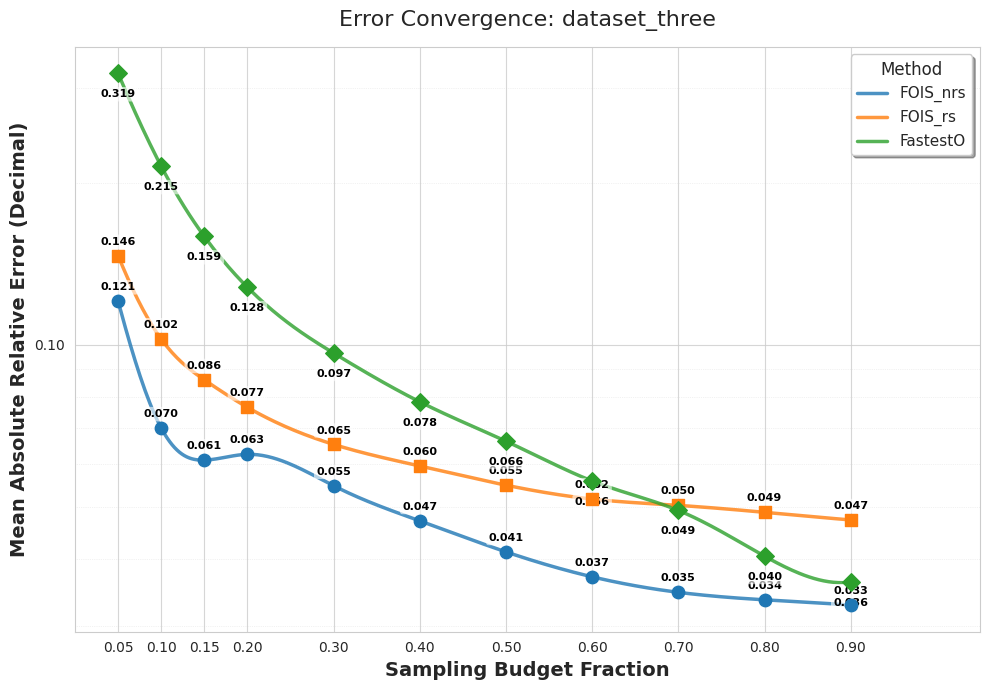


====== Data Summary (Filtered Points) ======
method       FOIS_nrs   FOIS_rs  FastestO
budget_frac                              
0.05         0.120510  0.146449  0.319406
0.10         0.070055  0.102482  0.214684
0.15         0.061069  0.086102  0.158999
0.20         0.062597  0.076536  0.127941
0.30         0.054721  0.065310  0.096532
0.40         0.047087  0.059544  0.078360
0.50         0.041237  0.054855  0.066203
0.60         0.037062  0.051686  0.055841
0.70         0.034682  0.050314  0.049234
0.80         0.033588  0.048843  0.040483
0.90         0.032832  0.047272  0.036222


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
from matplotlib.ticker import FuncFormatter, ScalarFormatter
from scipy.interpolate import make_interp_spline

# ==========================================
# 1. 配置参数
# ==========================================
dataset_name = 'dataset_three'
base_dir = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results/efficiency"

# 文件路径
path_fois = os.path.join(base_dir, "FOIS_rs_POSS_budget_curve.csv")
path_fast = os.path.join(base_dir, "FastestO_budget_curve.csv")
path_proxy = os.path.join(base_dir, "two_stage_adaptive_results.csv")

# 绘图配置
X_AXIS_COL = "budget_frac"
X_LABEL = "Sampling Budget Fraction"

TARGET_TICKS = [0.01, 0.05, 0.1, 0.2, 0.15, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
USE_ALL_DATA_FOR_CURVE = True

# ==========================================
# 2. 读取数据
# ==========================================
print("正在读取数据...")

# 2.1 读取 FOIS (这是现在的 Ground Truth 来源，必须存在)
if not os.path.exists(path_fois):
    print(f"[Error] FOIS 文件不存在 (基准文件缺失): {path_fois}")
    exit()
df_fois = pd.read_csv(path_fois)

# 2.2 读取 FastestO
dfs_to_merge = [df_fois]

if os.path.exists(path_fast):
    df_fast = pd.read_csv(path_fast)
    df_fast["method"] = "FastestO"
    dfs_to_merge.append(df_fast)
else:
    print(f"[Warn] FastestO 文件未找到: {path_fast}")

# 2.3 读取 Proxy Importance
if os.path.exists(path_proxy):
    df_proxy = pd.read_csv(path_proxy)
    # csv中已经包含了 method 列 (proxy_importance, proxyE_importance)
    dfs_to_merge.append(df_proxy)
else:
    print(f"[Warn] proxy_importance 文件未找到: {path_proxy}")

# ==========================================
# 3. 数据清洗与 GT 对齐 (以 FOIS 为 GT)
# ==========================================

# 3.1 第一步：统一文件名格式 (去除 .graph 后缀)
# 这一步非常重要，否则名字对不上，无法提取 T_true
for df in dfs_to_merge:
    if "query_basename" in df.columns:
        df["query_basename"] = df["query_basename"].astype(str).str.replace(r"\.graph$", "", regex=True)

# 3.2 第二步：从 FOIS 中提取 Ground Truth 字典
# [核心修改] 这里改成 df_fois
truth_map = df_fois[["query_basename", "T_true"]].drop_duplicates(subset=["query_basename"]).set_index("query_basename")["T_true"].to_dict()

print(f"-> 以 FOIS 为基准，加载了 {len(truth_map)} 条 Ground Truth。")

# 3.3 第三步：将 GT 映射到其他数据上
df_final_list = []
cols = ["query_basename", "method", X_AXIS_COL, "T_hat", "T_true"]

for df in dfs_to_merge:
    temp_df = df.copy()
    
    # [核心修改] 如果不是 FOIS，就强制用 FOIS 的 Truth 覆盖
    if df is not df_fois:
        temp_df["T_true"] = temp_df["query_basename"].map(truth_map)
        
        # 丢弃那些在 FOIS 里没找到对应 GT 的行
        # (例如 FastestO 跑了一个 FOIS 没跑的 query，由于没有真值，无法计算误差，必须丢弃)
        before_len = len(temp_df)
        temp_df = temp_df.dropna(subset=["T_true"])
        after_len = len(temp_df)
        if before_len > after_len:
            print(f"   [Info] {temp_df['method'].iloc[0] if not temp_df.empty else 'Unknown'} 丢弃了 {before_len - after_len} 行匹配不到 GT 的数据")

    # 提取需要的列
    if set(cols).issubset(temp_df.columns):
        df_final_list.append(temp_df[cols])

df_all = pd.concat(df_final_list, ignore_index=True)

# ==========================================
# 4. 计算误差
# ==========================================
df_all["ARE"] = ((df_all["T_hat"] - df_all["T_true"]) / df_all["T_true"]).abs()

# ==========================================
# 5. 数据聚合
# ==========================================
df_plot = df_all.groupby(["method", X_AXIS_COL])["ARE"].mean().reset_index()

# ==========================================
# 6. 绘图
# ==========================================
sns.set_style("whitegrid", {"grid.linestyle": "--"})
plt.figure(figsize=(10, 7))

# 定义顺序
desired_order = ["FOIS_nrs", "FOIS_rs", "POSS", "FastestO", "proxy_importance", "proxyE_importance"]
hue_order = [m for m in desired_order if m in df_plot["method"].unique()]

# 颜色与标记
palette = sns.color_palette("tab10", n_colors=len(hue_order))
color_map = dict(zip(hue_order, palette))
marker_map = dict(zip(desired_order, ["o", "s", "^", "D", "v", "X"]))

for method in hue_order:
    subset = df_plot[df_plot["method"] == method].sort_values(by=X_AXIS_COL)

    x_raw = subset[X_AXIS_COL].values
    y_raw = subset["ARE"].values

    # 过滤显示点
    mask_target = []
    for x_val in x_raw:
        is_target = any(np.isclose(x_val, t, atol=1e-4) for t in TARGET_TICKS)
        mask_target.append(is_target)
    mask_target = np.array(mask_target)

    if USE_ALL_DATA_FOR_CURVE:
        x_fit, y_fit = x_raw, y_raw
    else:
        x_fit, y_fit = x_raw[mask_target], y_raw[mask_target]

    # 绘制曲线 (带容错)
    if len(x_fit) > 2:
        try:
            x_new = np.linspace(x_fit.min(), x_fit.max(), 300)
            spl = make_interp_spline(x_fit, y_fit, k=3)
            y_smooth = spl(x_new)
            y_smooth = np.maximum(y_smooth, 0)
            plt.plot(x_new, y_smooth, color=color_map[method], linewidth=2.5, alpha=0.8, label=method)
        except:
            plt.plot(x_fit, y_fit, color=color_map[method], linewidth=2.5, alpha=0.8, label=method)
    else:
        plt.plot(x_fit, y_fit, color=color_map[method], linewidth=2.5, alpha=0.8, label=method)

    # 绘制散点
    x_markers = x_raw[mask_target]
    y_markers = y_raw[mask_target]
    if len(x_markers) > 0:
        plt.scatter(x_markers, y_markers, color=color_map[method], marker=marker_map.get(method, "o"), s=80, zorder=5)
        
        # 绘制标签
        for i in range(len(x_markers)):
            x_val = x_markers[i]
            y_val = y_markers[i]
            label_text = f"{y_val:.3f}"

            # 智能偏移
            xytext_offset = (0, 10)
            if method == "FastestO": xytext_offset = (0, -15)
            elif method == "proxy_importance": xytext_offset = (0, 15)
            elif method == "proxyE_importance": xytext_offset = (0, -15)
            elif method == "POSS": xytext_offset = (0, 10)

            plt.annotate(
                label_text,
                xy=(x_val, y_val),
                xytext=xytext_offset,
                textcoords="offset points",
                ha="center", va="center",
                fontsize=8, fontweight="bold", color="black",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6, ec="none")
            )

ax = plt.gca()
plt.xscale("linear")
plt.xlabel(X_LABEL, fontsize=14, fontweight="bold")
plt.xlim(0, 1.05)

min_x_plot = df_plot[X_AXIS_COL].min()
max_x_plot = df_plot[X_AXIS_COL].max()
final_ticks = [t for t in TARGET_TICKS if min_x_plot * 0.9 <= t <= max_x_plot * 1.1]
ax.set_xticks(final_ticks)
ax.get_xaxis().set_major_formatter(ScalarFormatter())

plt.yscale("log")
plt.ylabel("Mean Absolute Relative Error (Decimal)", fontsize=14, fontweight="bold")

def decimal_formatter(x, pos):
    if x < 0.01: return f"{x:.3f}"
    if x < 0.1:  return f"{x:.2f}"
    return f"{x:.2f}"

ax.yaxis.set_major_formatter(FuncFormatter(decimal_formatter))
ax.yaxis.set_minor_formatter(FuncFormatter(lambda x, _: ""))

plt.title(f"Error Convergence: {dataset_name}", fontsize=16, pad=15)
plt.legend(title="Method", fontsize=11, title_fontsize=12, loc="best", frameon=True, shadow=True)

plt.grid(True, which="major", linestyle="-", linewidth=0.8, alpha=0.8)
plt.grid(True, which="minor", linestyle=":", linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

print("\n====== Data Summary (Filtered Points) ======")
mask_all = df_plot[X_AXIS_COL].apply(lambda x: any(np.isclose(x, t, atol=1e-4) for t in TARGET_TICKS))
print(df_plot[mask_all].pivot(index=X_AXIS_COL, columns="method", values="ARE"))

##### 4.6添加proxyE
将 FOIS_nrs \ FOIS_rs \ FastestO \ 四种分层采样

正在读取数据...
正在处理数据...


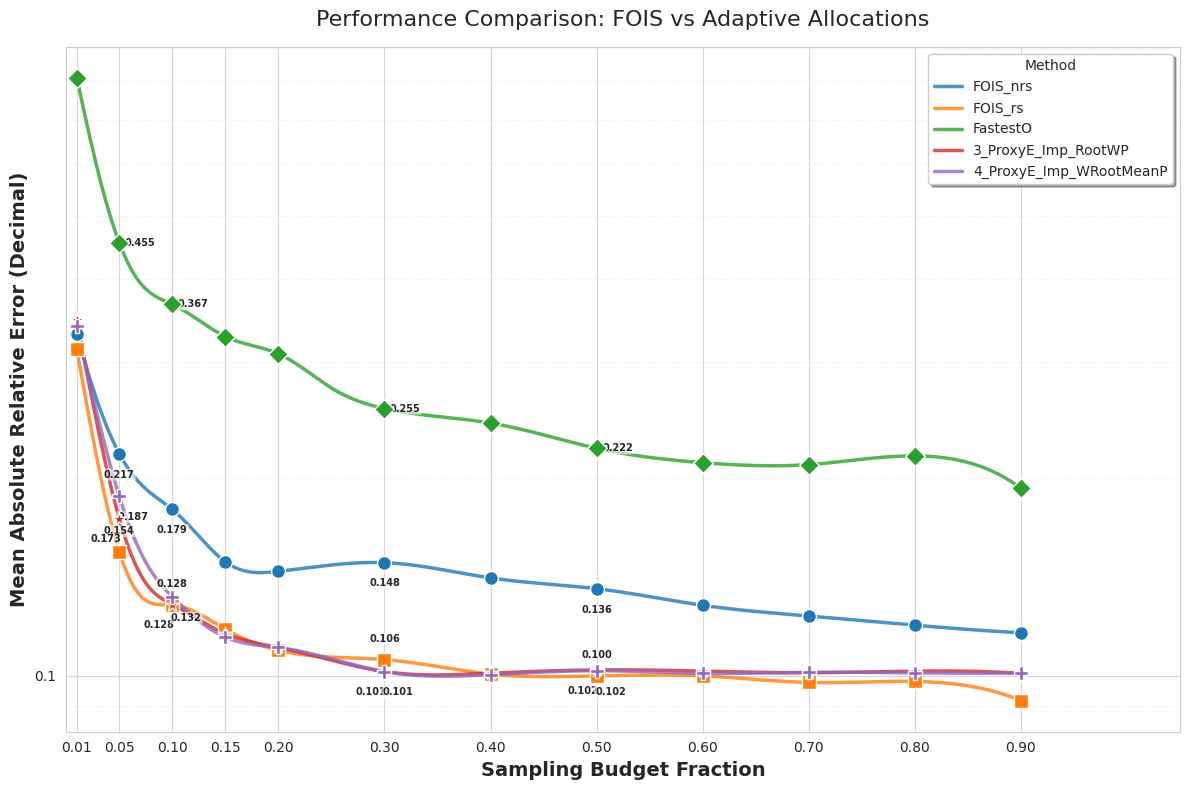


====== Summary (Pivot) ======
method       1_Proxy_Imp_Pilot  2_ProxyE_Imp_Pilot  3_ProxyE_Imp_RootWP  \
budget_frac                                                               
0.01                  0.574910            0.636265             0.347014   
0.05                  0.238360            0.298493             0.173231   
0.10                  0.166076            0.190048             0.128252   
0.15                  0.152205            0.133495             0.115818   
0.20                  0.111323            0.123061             0.110341   
0.30                  0.111016            0.104783             0.101416   
0.40                  0.104396            0.102787             0.100843   
0.50                  0.113105            0.104166             0.102006   
0.60                  0.101177            0.101535             0.101593   
0.70                  0.157773            0.100420             0.101005   
0.80                  0.100529            0.102504             0.1015

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
from matplotlib.ticker import FuncFormatter, ScalarFormatter
from scipy.interpolate import make_interp_spline

# ==========================================
# 1. 配置参数
# ==========================================
dataset_name = 'dataset_test'
base_dir = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results/efficiency"

# --- 文件路径 ---
# path_fois = os.path.join(base_dir, "FOIS_rs_POSS_budget_curve.csv")    # 这里面通常包含 FOIS_nrs 和 FOIS_rs
path_fast = os.path.join(base_dir, "FastestO_budget_curve.csv")
path_fois = os.path.join(base_dir, "FOIS_rs_FOSS_nrs_budget_curve_fast.csv")
path_alloc_new = os.path.join(base_dir, "allocation_strategy_comparison.csv")

# --- 绘图配置 ---
X_AXIS_COL = "budget_frac"
X_LABEL = "Sampling Budget Fraction"

TARGET_TICKS = [0.01, 0.05, 0.1, 0.15,0.2,0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
USE_ALL_DATA_FOR_CURVE = True

# ==========================================
# 2. 读取数据
# ==========================================
print("正在读取数据...")

dfs_to_merge = []

# 2.1 读取 FOIS (包含 nrs 和 rs)
if not os.path.exists(path_fois):
    print(f"[Error] FOIS 文件不存在: {path_fois}")
    exit()
df_fois = pd.read_csv(path_fois)
dfs_to_merge.append(df_fois)

# 2.2 读取 FastestO
if os.path.exists(path_fast):
    df_fast = pd.read_csv(path_fast)
    df_fast["method"] = "FastestO"
    dfs_to_merge.append(df_fast)

# 2.3 读取 新的策略对比
if os.path.exists(path_alloc_new):
    df_alloc = pd.read_csv(path_alloc_new)
    dfs_to_merge.append(df_alloc)
else:
    print(f"[Warn] 新策略文件未找到: {path_alloc_new}")

# ==========================================
# 3. 数据清洗与 GT 对齐
# ==========================================
print("正在处理数据...")

# 3.1 统一文件名
for df in dfs_to_merge:
    if "query_basename" in df.columns:
        df["query_basename"] = df["query_basename"].astype(str).str.replace(r"\.graph$", "", regex=True)

# 3.2 提取 GT 字典 (以 FOIS 文件为准)
truth_map = df_fois[["query_basename", "T_true"]].drop_duplicates(subset=["query_basename"]).set_index("query_basename")["T_true"].to_dict()

# 3.3 合并
df_final_list = []
cols = ["query_basename", "method", X_AXIS_COL, "T_hat", "T_true"]

for df in dfs_to_merge:
    temp_df = df.copy()
    if df is not df_fois:
        temp_df["T_true"] = temp_df["query_basename"].map(truth_map)
        temp_df = temp_df.dropna(subset=["T_true"])
    
    if set(cols).issubset(temp_df.columns):
        df_final_list.append(temp_df[cols])

df_all = pd.concat(df_final_list, ignore_index=True)

# ==========================================
# 4. 计算误差
# ==========================================
df_all = df_all[df_all["T_true"] != 0]
df_all["ARE"] = ((df_all["T_hat"] - df_all["T_true"]) / df_all["T_true"]).abs()

# ==========================================
# 5. 聚合
# ==========================================
df_plot = df_all.groupby(["method", X_AXIS_COL])["ARE"].mean().reset_index()

# ==========================================
# 6. 绘图 (核心修改)
# ==========================================
sns.set_style("whitegrid", {"grid.linestyle": "--"})
plt.figure(figsize=(12, 8))

# --- [修改点 1] 添加 FOIS_nrs 到顺序列表 ---
desired_order = [
    "FOIS_nrs",             # <--- 新增
    "FOIS_rs", 
    "FastestO",
    # "1_Proxy_Imp_Pilot",
    # "2_ProxyE_Imp_Pilot",
    "3_ProxyE_Imp_RootWP",
    "4_ProxyE_Imp_WRootMeanP"
]
hue_order = [m for m in desired_order if m in df_plot["method"].unique()]

palette = sns.color_palette("tab10", n_colors=len(hue_order))
color_map = dict(zip(hue_order, palette))

# --- [修改点 2] 为 FOIS_nrs 分配 Marker ---
marker_dict = {
    "FOIS_nrs": "o",            # 圆圈 (和 rs 区分)
    "FOIS_rs": "s",             # 方块
    "FastestO": "D",            # 菱形
    
    "1_Proxy_Imp_Pilot": "p",      # 五边形 (原先是o，改为p避免冲突)
    "2_ProxyE_Imp_Pilot": "X",     # 叉号
    "3_ProxyE_Imp_RootWP": "*",    # 星号
    "4_ProxyE_Imp_WRootMeanP": "P" # 加号
}

# --- [修改点 3] 为 FOIS_nrs 分配 标签偏移 ---
offset_map = {
    "FOIS_nrs": (0, -15),        # 向下
    "FOIS_rs": (0, 15),          # 向上
    "FastestO": (15, 0),         # 向右
    
    "1_Proxy_Imp_Pilot": (-10, 10),
    "2_ProxyE_Imp_Pilot": (10, 10),
    "3_ProxyE_Imp_RootWP": (-10, -15),
    "4_ProxyE_Imp_WRootMeanP": (10, -15)
}

default_offset = (0, 10)

for method in hue_order:
    subset = df_plot[df_plot["method"] == method].sort_values(by=X_AXIS_COL)
    x_raw = subset[X_AXIS_COL].values
    y_raw = subset["ARE"].values

    # 平滑曲线
    if len(x_raw) > 3 and USE_ALL_DATA_FOR_CURVE:
        try:
            x_new = np.linspace(x_raw.min(), x_raw.max(), 300)
            spl = make_interp_spline(x_raw, y_raw, k=3)
            y_smooth = spl(x_new)
            y_smooth = np.maximum(y_smooth, 0)
            plt.plot(x_new, y_smooth, color=color_map[method], linewidth=2.5, alpha=0.8, label=method)
        except:
            plt.plot(x_raw, y_raw, color=color_map[method], linewidth=2.5, alpha=0.8, label=method)
    else:
        plt.plot(x_raw, y_raw, color=color_map[method], linewidth=2.5, alpha=0.8, label=method)

    # 散点
    mask = [any(np.isclose(x, t, atol=1e-3) for t in TARGET_TICKS) for x in x_raw]
    x_pts = x_raw[mask]
    y_pts = y_raw[mask]
    
    if len(x_pts) > 0:
        mk = marker_dict.get(method, "o")
        plt.scatter(x_pts, y_pts, color=color_map[method], marker=mk, s=100, zorder=5, edgecolor='white', linewidth=1)

        # 标签
        for i in range(len(x_pts)):
            # 仅在关键点显示数值，避免拥挤
            if x_pts[i] in [0.05, 0.1, 0.3, 0.5, 1.0]: 
                lbl = f"{y_pts[i]:.3f}"
                off = offset_map.get(method, default_offset)
                
                plt.annotate(
                    lbl, 
                    xy=(x_pts[i], y_pts[i]), 
                    xytext=off,
                    textcoords="offset points",
                    ha="center", va="center",
                    fontsize=7, fontweight="bold",
                    bbox=dict(boxstyle="round,pad=0.1", fc="white", alpha=0.6, ec="none")
                )

ax = plt.gca()
plt.xscale("linear")
plt.xlabel(X_LABEL, fontsize=14, fontweight="bold")
plt.xlim(0, 1.05)

min_x = df_plot[X_AXIS_COL].min()
max_x = df_plot[X_AXIS_COL].max()
final_ticks = [t for t in TARGET_TICKS if min_x * 0.9 <= t <= max_x * 1.1]
ax.set_xticks(final_ticks)
ax.get_xaxis().set_major_formatter(ScalarFormatter())

plt.yscale("log")
plt.ylabel("Mean Absolute Relative Error (Decimal)", fontsize=14, fontweight="bold")
def decimal_formatter(x, pos): return f"{x:.2g}"
ax.yaxis.set_major_formatter(FuncFormatter(decimal_formatter))

plt.title(f"Performance Comparison: FOIS vs Adaptive Allocations", fontsize=16, pad=15)
plt.legend(title="Method", fontsize=10, loc="best", frameon=True, shadow=True)

plt.grid(True, which="major", linestyle="-", linewidth=0.8, alpha=0.8)
plt.grid(True, which="minor", linestyle=":", linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

# 打印数据
print("\n====== Summary (Pivot) ======")
df_filtered = df_plot[df_plot[X_AXIS_COL].apply(lambda x: any(np.isclose(x, t, atol=1e-3) for t in TARGET_TICKS))]
print(df_filtered.pivot(index=X_AXIS_COL, columns="method", values="ARE"))

#### 5.

##### 5.1添加proxyE
读取上面相应文件,在指定采样率下,对于每个方法(FOIS_nrs \ FOIS_rs \ FastestO \ 四种分层采样)绘制绝对平均误差的CDF图

正在读取并对齐数据...


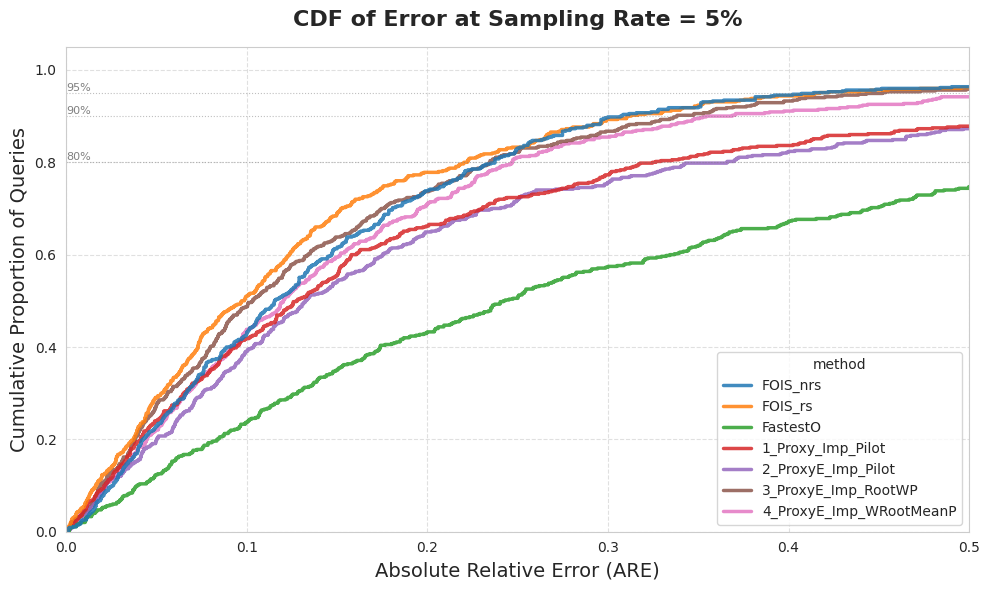


  AQP Evaluation Metrics Summary (Dynamic Percentiles) [Budget=0.05]
Method                    | Mean       | Median     | P50        | P75        | P90        | P95        | Max       
---------------------------------------------------------------------------------------------------------
FOIS_nrs                  | 0.2174     | 0.1155     | 0.1155     | 0.2091     | 0.3070     | 0.4109     | 27.7731   
FOIS_rs                   | 0.1542     | 0.0978     | 0.0978     | 0.1776     | 0.3110     | 0.4160     | 2.7334    
FastestO                  | 0.4547     | 0.2426     | 0.2426     | 0.5053     | 1.0000     | 1.0000     | 11.4411   
1_Proxy_Imp_Pilot         | 0.2384     | 0.1277     | 0.1277     | 0.2810     | 0.6128     | 1.0000     | 2.4186    
2_ProxyE_Imp_Pilot        | 0.2985     | 0.1326     | 0.1326     | 0.2967     | 0.6726     | 1.0000     | 8.6535    
3_ProxyE_Imp_RootWP       | 0.1732     | 0.1033     | 0.1033     | 0.2059     | 0.3380     | 0.4480     | 3.4216    
4_Pro

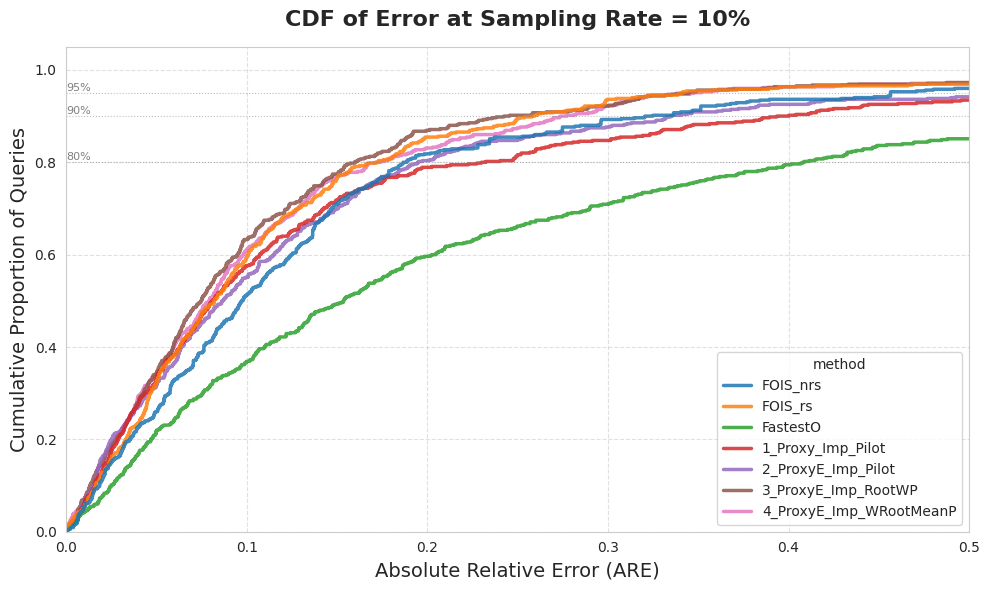


  AQP Evaluation Metrics Summary (Dynamic Percentiles) [Budget=0.1]
Method                    | Mean       | Median     | P50        | P75        | P90        | P95        | Max       
---------------------------------------------------------------------------------------------------------
FOIS_nrs                  | 0.1788     | 0.0974     | 0.0974     | 0.1676     | 0.3210     | 0.4565     | 14.4425   
FOIS_rs                   | 0.1281     | 0.0820     | 0.0820     | 0.1471     | 0.2581     | 0.3401     | 1.7879    
FastestO                  | 0.3667     | 0.1535     | 0.1535     | 0.3400     | 0.6664     | 1.0000     | 11.9339   
1_Proxy_Imp_Pilot         | 0.1661     | 0.0808     | 0.0808     | 0.1692     | 0.3942     | 0.5810     | 2.8088    
2_ProxyE_Imp_Pilot        | 0.1900     | 0.0865     | 0.0865     | 0.1664     | 0.3348     | 0.5697     | 12.0553   
3_ProxyE_Imp_RootWP       | 0.1283     | 0.0747     | 0.0747     | 0.1405     | 0.2427     | 0.3417     | 2.5284    
4_Prox

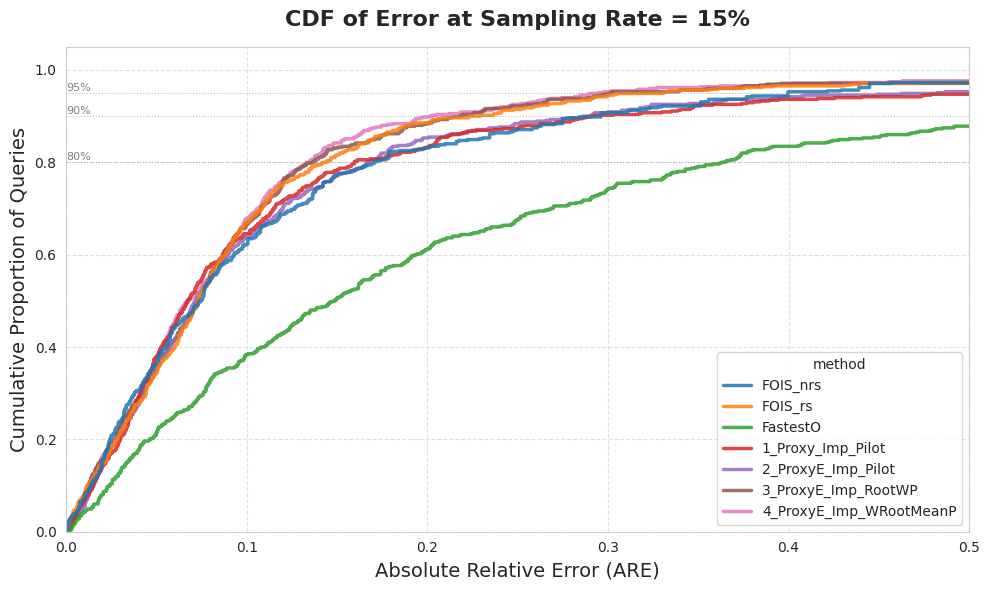


  AQP Evaluation Metrics Summary (Dynamic Percentiles) [Budget=0.15]
Method                    | Mean       | Median     | P50        | P75        | P90        | P95        | Max       
---------------------------------------------------------------------------------------------------------
FOIS_nrs                  | 0.1489     | 0.0745     | 0.0745     | 0.1422     | 0.2961     | 0.3997     | 9.5295    
FOIS_rs                   | 0.1177     | 0.0730     | 0.0730     | 0.1194     | 0.2237     | 0.3190     | 2.0621    
FastestO                  | 0.3276     | 0.1485     | 0.1485     | 0.3043     | 0.6022     | 1.0000     | 11.1920   
1_Proxy_Imp_Pilot         | 0.1522     | 0.0673     | 0.0673     | 0.1351     | 0.2908     | 0.5209     | 4.4434    
2_ProxyE_Imp_Pilot        | 0.1335     | 0.0718     | 0.0718     | 0.1420     | 0.2866     | 0.4734     | 1.9900    
3_ProxyE_Imp_RootWP       | 0.1158     | 0.0722     | 0.0722     | 0.1194     | 0.2180     | 0.3009     | 2.0514    
4_Pro

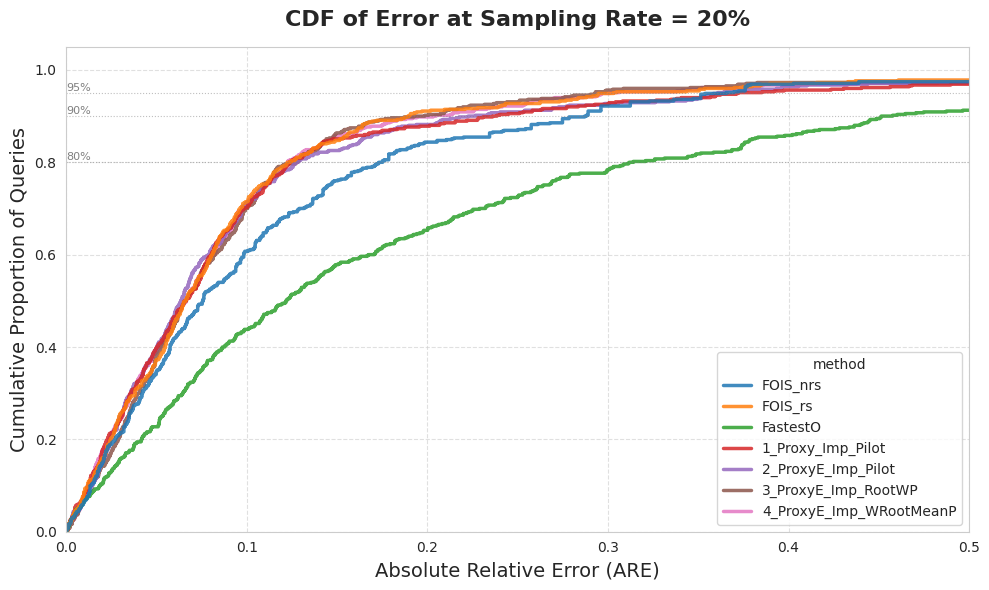


  AQP Evaluation Metrics Summary (Dynamic Percentiles) [Budget=0.2]
Method                    | Mean       | Median     | P50        | P75        | P90        | P95        | Max       
---------------------------------------------------------------------------------------------------------
FOIS_nrs                  | 0.1441     | 0.0757     | 0.0757     | 0.1450     | 0.2872     | 0.3602     | 7.0530    
FOIS_rs                   | 0.1092     | 0.0660     | 0.0660     | 0.1078     | 0.1892     | 0.2994     | 2.1247    
FastestO                  | 0.3084     | 0.1218     | 0.1218     | 0.2641     | 0.4520     | 0.6800     | 12.2691   
1_Proxy_Imp_Pilot         | 0.1113     | 0.0660     | 0.0660     | 0.1107     | 0.2363     | 0.3716     | 1.9048    
2_ProxyE_Imp_Pilot        | 0.1231     | 0.0635     | 0.0635     | 0.1100     | 0.2230     | 0.3598     | 2.8459    
3_ProxyE_Imp_RootWP       | 0.1103     | 0.0662     | 0.0662     | 0.1091     | 0.1932     | 0.2928     | 1.8115    
4_Prox

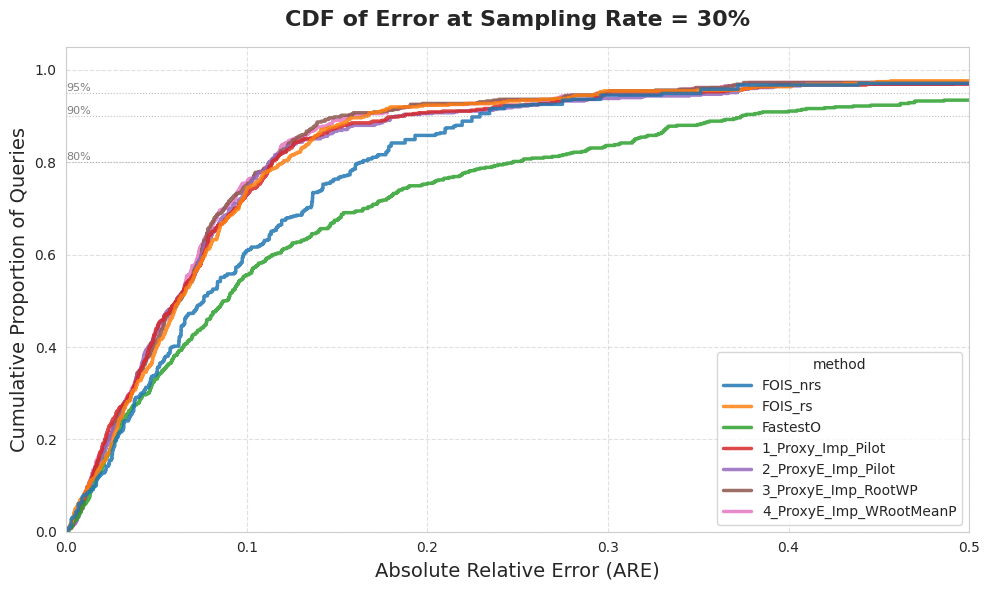


  AQP Evaluation Metrics Summary (Dynamic Percentiles) [Budget=0.3]
Method                    | Mean       | Median     | P50        | P75        | P90        | P95        | Max       
---------------------------------------------------------------------------------------------------------
FOIS_nrs                  | 0.1485     | 0.0761     | 0.0761     | 0.1422     | 0.2291     | 0.3416     | 4.6076    
FOIS_rs                   | 0.1058     | 0.0625     | 0.0625     | 0.1027     | 0.1653     | 0.2948     | 1.9801    
FastestO                  | 0.2547     | 0.0880     | 0.0880     | 0.1949     | 0.3738     | 0.5891     | 11.7149   
1_Proxy_Imp_Pilot         | 0.1110     | 0.0610     | 0.0610     | 0.1060     | 0.1844     | 0.3289     | 2.5753    
2_ProxyE_Imp_Pilot        | 0.1048     | 0.0610     | 0.0610     | 0.1014     | 0.1825     | 0.3649     | 2.0280    
3_ProxyE_Imp_RootWP       | 0.1014     | 0.0624     | 0.0624     | 0.0998     | 0.1518     | 0.2952     | 1.7729    
4_Prox

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

# ==========================================
# 1. 配置参数
# ==========================================
dataset_name = 'dataset_test'
base_dir = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results/efficiency"

# 文件路径
# path_fois = os.path.join(base_dir, "FOIS_rs_POSS_budget_curve.csv")
path_fois = os.path.join(base_dir, "FOIS_rs_FOSS_nrs_budget_curve_fast.csv")
path_fast = os.path.join(base_dir, "FastestO_budget_curve.csv")
path_alloc = os.path.join(base_dir, "allocation_strategy_comparison.csv")

# --- 指定要绘制 CDF 的采样率 (Budget Fraction) ---
PLOTTING_BUDGETS = [0.05, 0.1,0.15,0.2, 0.3] 

# x轴截断
X_LIMIT = 0.5

# ==========================================
# 2. 数据加载与对齐
# ==========================================
print("正在读取并对齐数据...")

dfs = []

# 2.1 加载 FOIS (基准)
if os.path.exists(path_fois):
    df_fois = pd.read_csv(path_fois)
    dfs.append(df_fois)
    df_fois["query_basename"] = df_fois["query_basename"].astype(str).str.replace(r"\.graph$", "", regex=True)
    truth_map = df_fois[["query_basename", "T_true"]].drop_duplicates(subset=["query_basename"]).set_index("query_basename")["T_true"].to_dict()
else:
    print(f"[Error] 基准文件缺失: {path_fois}")
    exit()

# 2.2 加载 FastestO
if os.path.exists(path_fast):
    df_fast = pd.read_csv(path_fast)
    df_fast["method"] = "FastestO"
    dfs.append(df_fast)

# 2.3 加载 分层策略对比
if os.path.exists(path_alloc):
    df_alloc = pd.read_csv(path_alloc)
    dfs.append(df_alloc)

# 2.4 合并与计算 ARE
df_final_list = []
target_cols = ["query_basename", "method", "budget_frac", "T_hat", "T_true"]

for df in dfs:
    temp = df.copy()
    if "query_basename" in temp.columns:
        temp["query_basename"] = temp["query_basename"].astype(str).str.replace(r"\.graph$", "", regex=True)
    
    if df is not df_fois:
        temp["T_true"] = temp["query_basename"].map(truth_map)
        temp = temp.dropna(subset=["T_true"])

    if set(target_cols).issubset(temp.columns):
        df_final_list.append(temp[target_cols])

df_all = pd.concat(df_final_list, ignore_index=True)

# 计算绝对相对误差 (ARE)
df_all = df_all[df_all["T_true"] != 0]
df_all["ARE"] = ((df_all["T_hat"] - df_all["T_true"]) / df_all["T_true"]).abs()

# ==========================================
# 3. 绘图配置
# ==========================================
desired_order = [
    "FOIS_nrs", "FOIS_rs", "FastestO",
    "1_Proxy_Imp_Pilot", "2_ProxyE_Imp_Pilot", 
    "3_ProxyE_Imp_RootWP", "4_ProxyE_Imp_WRootMeanP"
]
available_methods = [m for m in desired_order if m in df_all["method"].unique()]

palette = sns.color_palette("tab10", n_colors=len(available_methods))
color_map = dict(zip(available_methods, palette))

# ==========================================
# 4. 循环绘制 CDF 及 打印详细统计
# ==========================================
sns.set_style("whitegrid")

for budget in PLOTTING_BUDGETS:
    # 筛选数据
    mask = df_all["budget_frac"].apply(lambda x: np.isclose(x, budget, atol=1e-4))
    subset = df_all[mask].copy()
    
    if subset.empty:
        print(f"[Warn] Budget = {budget} 没有找到任何数据行，跳过绘图。")
        continue

    subset = subset.dropna(subset=["ARE"])
    if subset.empty:
        print(f"[Warn] Budget = {budget} 的 ARE 全为 NaN，跳过绘图。")
        continue

    current_methods = [m for m in desired_order if m in subset["method"].unique()]
    
    if not current_methods:
        continue

    # --- 绘图 ---
    plt.figure(figsize=(10, 6))
    
    ax = sns.ecdfplot(
        data=subset, 
        x="ARE", 
        hue="method", 
        hue_order=current_methods,
        palette=color_map,
        linewidth=2.5,
        alpha=0.85
    )

    plt.title(f"CDF of Error at Sampling Rate = {int(budget*100)}%", fontsize=16, fontweight="bold", pad=15)
    plt.xlabel("Absolute Relative Error (ARE)", fontsize=14)
    plt.ylabel("Cumulative Proportion of Queries", fontsize=14)
    
    if X_LIMIT:
        plt.xlim(0, X_LIMIT)
    plt.ylim(0, 1.05)
    
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        plt.legend(handles=handles, labels=labels, title="Method", fontsize=10, loc="lower right", frameon=True, shadow=True)

    plt.grid(True, linestyle="--", alpha=0.6)
    for y_line in [0.8, 0.9, 0.95]:
        plt.axhline(y=y_line, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
        plt.text(0, y_line, f"{int(y_line*100)}%", color='gray', fontsize=8, va="bottom")

    plt.tight_layout()
    plt.show()
    
    # =========================================================
    # --- [关键修改] 打印详细统计表格 ---
    # =========================================================
    stats_data = []
    for m in current_methods:
        m_data = subset[subset["method"] == m]["ARE"]
        if not m_data.empty:
            stats_data.append({
                "Method": m,
                "Mean": m_data.mean(),
                "Median": m_data.median(),
                "P50": m_data.median(), # Median 和 P50 是同一个值，这里按要求列出
                "P75": m_data.quantile(0.75),
                "P90": m_data.quantile(0.90),
                "P95": m_data.quantile(0.95),
                "Max": m_data.max()
            })
            
    # 如果有统计数据，进行格式化输出
    if stats_data:
        print(f"\n  AQP Evaluation Metrics Summary (Dynamic Percentiles) [Budget={budget}]")
        print("=" * 105)
        # 表头
        print(f"{'Method':<25} | {'Mean':<10} | {'Median':<10} | {'P50':<10} | {'P75':<10} | {'P90':<10} | {'P95':<10} | {'Max':<10}")
        print("-" * 105)
        
        # 数据行
        for row in stats_data:
            print(f"{row['Method']:<25} | "
                  f"{row['Mean']:<10.4f} | "
                  f"{row['Median']:<10.4f} | "
                  f"{row['P50']:<10.4f} | "
                  f"{row['P75']:<10.4f} | "
                  f"{row['P90']:<10.4f} | "
                  f"{row['P95']:<10.4f} | "
                  f"{row['Max']:<10.4f}")
        print("=" * 105 + "\n")